# Section 5. Sampling and Splitting Data

In this section, we cover:

1. Random train-test split  
2. Stratified train-test split  
3. Checking class balance  
4. Oversampling minority class  
5. Undersampling majority class  
6. Class weights  

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [62]:

# 1. Load Titanic Dataset from OpenML
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML
print('Fetching LendingClub dataset from OpenML...')
# Using a common OpenML version of lending club
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


In [63]:
titanic_model = titanic_df.copy()

target_col = "survived"

# Convert target to integer
titanic_model[target_col] = titanic_model[target_col].astype(int)

# Treat pclass as categorical
if "pclass" in titanic_model.columns:
    titanic_model["pclass"] = titanic_model["pclass"].astype("category")

# Separate X and y FIRST
X_titanic = titanic_model.drop(columns=[target_col]).copy()
y_titanic = titanic_model[target_col].copy()

# Drop high-cardinality / leakage-like columns if present
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_titanic = X_titanic.drop(columns=cols_to_drop, errors="ignore")

# Identify categorical and numeric columns
cat_cols = X_titanic.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()
num_cols = X_titanic.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_titanic[col] = X_titanic[col].astype("object")
    X_titanic[col] = X_titanic[col].fillna("missing")
    X_titanic[col] = X_titanic[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_imputer = SimpleImputer(strategy="median")
X_titanic[num_cols] = num_imputer.fit_transform(X_titanic[num_cols])

# One-hot encode categorical columns
X_titanic = pd.get_dummies(
    X_titanic,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Titanic X shape:", X_titanic.shape)
print("Titanic y shape:", y_titanic.shape)

display(X_titanic.head())
display(y_titanic.value_counts())
display(y_titanic.value_counts(normalize=True))

Titanic X shape: (1309, 10)
Titanic y shape: (1309,)


,age,sibsp,parch,fare,pclass_2,pclass_3,sex_male,embarked_missing,embarked_q,embarked_s
0,29.0000,0.0,0.0,211.3375,0,0,0,0,0,1
1,0.9167,1.0,2.0,151.5500,0,0,1,0,0,1
2,2.0000,1.0,2.0,151.5500,0,0,0,0,0,1
3,30.0000,1.0,2.0,151.5500,0,0,1,0,0,1
4,25.0000,1.0,2.0,151.5500,0,0,0,0,0,1


survived
0    809
1    500
Name: count, dtype: int64

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

### Random Train-Test Split

Random split divides data randomly into training and test sets.

This is simple, but for classification it may not preserve the class ratio.

In [64]:
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42
)

print("Random split:")
print("Train shape:", X_train_random.shape)
print("Test shape:", X_test_random.shape)

print("\nTrain target distribution:")
display(y_train_random.value_counts(normalize=True))

print("\nTest target distribution:")
display(y_test_random.value_counts(normalize=True))

Random split:
Train shape: (1047, 10)
Test shape: (262, 10)

Train target distribution:


survived
0    0.635148
1    0.364852
Name: proportion, dtype: float64


Test target distribution:


survived
0    0.549618
1    0.450382
Name: proportion, dtype: float64

### Stratified Train-Test Split

Stratified split preserves the target class distribution.

For Titanic, this keeps the survival rate similar in both train and test data.

In [65]:
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

print("Stratified split:")
print("Train shape:", X_train_strat.shape)
print("Test shape:", X_test_strat.shape)

print("\nTrain target distribution:")
display(y_train_strat.value_counts(normalize=True))

print("\nTest target distribution:")
display(y_test_strat.value_counts(normalize=True))

Stratified split:
Train shape: (1047, 10)
Test shape: (262, 10)

Train target distribution:


survived
0    0.617956
1    0.382044
Name: proportion, dtype: float64


Test target distribution:


survived
0    0.618321
1    0.381679
Name: proportion, dtype: float64

In [66]:
# Compare full, train, and test distributions

split_comparison = pd.DataFrame({
    "full_data": y_titanic.value_counts(normalize=True),
    "random_train": y_train_random.value_counts(normalize=True),
    "random_test": y_test_random.value_counts(normalize=True),
    "strat_train": y_train_strat.value_counts(normalize=True),
    "strat_test": y_test_strat.value_counts(normalize=True)
})

display(split_comparison)

,full_data,random_train,random_test,strat_train,strat_test
survived,,,,,
0,0.618029,0.635148,0.549618,0.617956,0.618321
1,0.381971,0.364852,0.450382,0.382044,0.381679


### Visualize Class Balance

For classification problems, class imbalance matters.

If one class is rare, accuracy can be misleading.

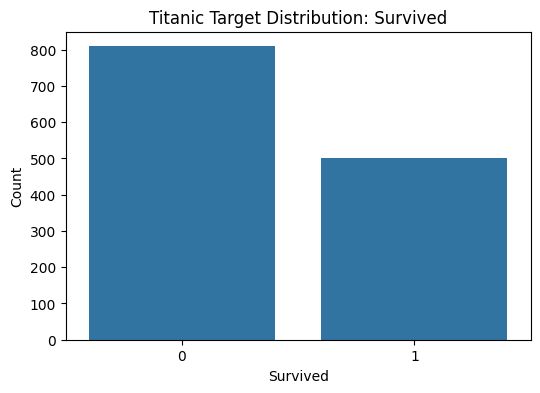

In [67]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_titanic)
plt.title("Titanic Target Distribution: Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

### Oversampling Minority Class

Oversampling duplicates examples from the minority class.

This can help the model learn the minority class better.

In [68]:
# Combine X_train and y_train for resampling

train_data = X_train_strat.copy()
train_data["target"] = y_train_strat.values

majority_class = train_data["target"].value_counts().idxmax()
minority_class = train_data["target"].value_counts().idxmin()

majority_df = train_data[train_data["target"] == majority_class]
minority_df = train_data[train_data["target"] == minority_class]

minority_oversampled = resample(
    minority_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=42
)

train_oversampled = pd.concat([majority_df, minority_oversampled])

X_train_over = train_oversampled.drop(columns=["target"])
y_train_over = train_oversampled["target"]

print("Before oversampling:")
display(y_train_strat.value_counts())

print("After oversampling:")
display(y_train_over.value_counts())

Before oversampling:


survived
0    647
1    400
Name: count, dtype: int64

After oversampling:


target
0    647
1    647
Name: count, dtype: int64

### Undersampling Majority Class

Undersampling reduces the number of majority-class examples.

This can balance the data but may remove useful information.

In [69]:
majority_undersampled = resample(
    majority_df,
    replace=False,
    n_samples=len(minority_df),
    random_state=42
)

train_undersampled = pd.concat([majority_undersampled, minority_df])

X_train_under = train_undersampled.drop(columns=["target"])
y_train_under = train_undersampled["target"]

print("Before undersampling:")
display(y_train_strat.value_counts())

print("After undersampling:")
display(y_train_under.value_counts())

Before undersampling:


survived
0    647
1    400
Name: count, dtype: int64

After undersampling:


target
0    400
1    400
Name: count, dtype: int64

### Class Weights

Class weights tell the model to penalize mistakes on minority classes more.

This avoids duplicating or removing data.

In [70]:
model_no_weights = LogisticRegression(max_iter=1000)

model_no_weights.fit(X_train_strat, y_train_strat)

y_pred_no_weights = model_no_weights.predict(X_test_strat)

print("Model without class weights:")
print(classification_report(y_test_strat, y_pred_no_weights))

Model without class weights:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       162
           1       0.76      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.81      0.80       262



In [71]:
model_with_weights = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_with_weights.fit(X_train_strat, y_train_strat)

y_pred_weights = model_with_weights.predict(X_test_strat)

print("Model with class weights:")
print(classification_report(y_test_strat, y_pred_weights))

Model with class weights:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       162
           1       0.70      0.78      0.74       100

    accuracy                           0.79       262
   macro avg       0.78      0.79      0.78       262
weighted avg       0.80      0.79      0.79       262



### Compare Sampling Approaches

We compare:

- Original stratified data
- Oversampled training data
- Undersampled training data
- Class-weighted model

In [72]:
def train_and_evaluate_logistic(X_train_input, y_train_input, X_test_input, y_test_input, model_name):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_input, y_train_input)
    preds = model.predict(X_test_input)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test_input, preds))
    
    return model

model_original = train_and_evaluate_logistic(
    X_train_strat,
    y_train_strat,
    X_test_strat,
    y_test_strat,
    "Original Stratified Training Data"
)

model_over = train_and_evaluate_logistic(
    X_train_over,
    y_train_over,
    X_test_strat,
    y_test_strat,
    "Oversampled Training Data"
)

model_under = train_and_evaluate_logistic(
    X_train_under,
    y_train_under,
    X_test_strat,
    y_test_strat,
    "Undersampled Training Data"
)

Original Stratified Training Data
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       162
           1       0.76      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.81      0.80       262

Oversampled Training Data
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       162
           1       0.71      0.78      0.74       100

    accuracy                           0.79       262
   macro avg       0.78      0.79      0.79       262
weighted avg       0.80      0.79      0.80       262

Undersampled Training Data
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       162
           1       0.71      0.78      0.74       100

    accuracy                           0.79       262
   macro avg       0.78      0.79      0.

## Titanic Section 5 Summary

For Titanic:

- Use stratified split because this is a classification problem.
- Oversampling balances the minority class by duplication.
- Undersampling balances the data by removing majority examples.
- Class weights are often a clean first option before resampling.

In [73]:
lc_model = lending_df.copy()

target_col = "not.fully.paid"

# Convert target to integer
lc_model[target_col] = lc_model[target_col].astype(int)

# Separate X and y FIRST
X_lc = lc_model.drop(columns=[target_col]).copy()
y_lc = lc_model[target_col].copy()

# Identify categorical and numeric columns
cat_cols = X_lc.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()
num_cols = X_lc.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_lc[col] = X_lc[col].astype("object")
    X_lc[col] = X_lc[col].fillna("missing")
    X_lc[col] = X_lc[col].astype(str).str.strip().str.lower()

# Impute numeric columns
num_imputer = SimpleImputer(strategy="median")
X_lc[num_cols] = num_imputer.fit_transform(X_lc[num_cols])

# One-hot encode categorical columns
X_lc = pd.get_dummies(
    X_lc,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Replace infinite values if any
X_lc = X_lc.replace([np.inf, -np.inf], np.nan)
X_lc = X_lc.fillna(X_lc.median(numeric_only=True))

print("LendingClub X shape:", X_lc.shape)
print("LendingClub y shape:", y_lc.shape)

display(X_lc.head())
display(y_lc.value_counts())
display(y_lc.value_counts(normalize=True))

LendingClub X shape: (9578, 18)
LendingClub y shape: (9578,)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,0.0,0.0,0,1,0,0,0,0
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,0.0,0.0,1,0,0,0,0,0
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,0.0,0.0,0,1,0,0,0,0
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,0.0,0.0,0,1,0,0,0,0
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,1.0,0.0,1,0,0,0,0,0


not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64

### Random Split

Random split may accidentally produce different default rates in train and test sets.

In [74]:
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42
)

print("Random split:")
print("Train shape:", X_train_random.shape)
print("Test shape:", X_test_random.shape)

print("\nTrain target distribution:")
display(y_train_random.value_counts(normalize=True))

print("\nTest target distribution:")
display(y_test_random.value_counts(normalize=True))

Random split:
Train shape: (7662, 18)
Test shape: (1916, 18)

Train target distribution:


not.fully.paid
0    0.839729
1    0.160271
Name: proportion, dtype: float64


Test target distribution:


not.fully.paid
0    0.840814
1    0.159186
Name: proportion, dtype: float64

### Stratified Split

Stratified split preserves the default / non-default ratio.

This is usually preferred for LendingClub.

In [75]:
X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42,
    stratify=y_lc
)

print("Stratified split:")
print("Train shape:", X_train_lc.shape)
print("Test shape:", X_test_lc.shape)

print("\nTrain target distribution:")
display(y_train_lc.value_counts(normalize=True))

print("\nTest target distribution:")
display(y_test_lc.value_counts(normalize=True))

Stratified split:
Train shape: (7662, 18)
Test shape: (1916, 18)

Train target distribution:


not.fully.paid
0    0.83999
1    0.16001
Name: proportion, dtype: float64


Test target distribution:


not.fully.paid
0    0.83977
1    0.16023
Name: proportion, dtype: float64

In [76]:
# Scale features — LendingClub has features on very different scales,
# which causes lbfgs to fail to converge without normalization.
scaler = StandardScaler()
X_train_lc = pd.DataFrame(
    scaler.fit_transform(X_train_lc),
    columns=X_train_lc.columns,
    index=X_train_lc.index
)
X_test_lc = pd.DataFrame(
    scaler.transform(X_test_lc),
    columns=X_test_lc.columns,
    index=X_test_lc.index
)

print("LendingClub features scaled (StandardScaler).")

LendingClub features scaled (StandardScaler).


In [77]:
split_comparison_lc = pd.DataFrame({
    "full_data": y_lc.value_counts(normalize=True),
    "random_train": y_train_random.value_counts(normalize=True),
    "random_test": y_test_random.value_counts(normalize=True),
    "strat_train": y_train_lc.value_counts(normalize=True),
    "strat_test": y_test_lc.value_counts(normalize=True)
})

display(split_comparison_lc)

,full_data,random_train,random_test,strat_train,strat_test
not.fully.paid,,,,,
0,0.839946,0.839729,0.840814,0.83999,0.83977
1,0.160054,0.160271,0.159186,0.16001,0.16023


### Visualize Imbalance

The positive class is `not.fully.paid = 1`.

This is the risky class and is often much smaller than the fully-paid class.

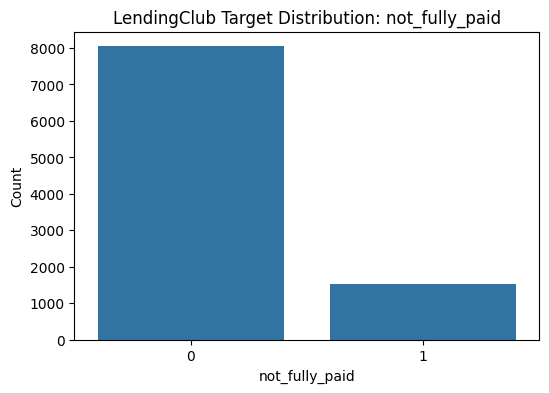

In [78]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_lc)
plt.title("LendingClub Target Distribution: not_fully_paid")
plt.xlabel("not_fully_paid")
plt.ylabel("Count")
plt.show()

### Oversampling Minority Class

Oversampling duplicates minority class examples.

Use it only on the training data, never on the test data.

In [79]:
train_lc = X_train_lc.copy()
train_lc["target"] = y_train_lc.values

majority_class = train_lc["target"].value_counts().idxmax()
minority_class = train_lc["target"].value_counts().idxmin()

majority_df = train_lc[train_lc["target"] == majority_class]
minority_df = train_lc[train_lc["target"] == minority_class]

minority_oversampled = resample(
    minority_df,
    replace=True,
    n_samples=len(majority_df),
    random_state=42
)

train_lc_oversampled = pd.concat([majority_df, minority_oversampled])

X_train_lc_over = train_lc_oversampled.drop(columns=["target"])
y_train_lc_over = train_lc_oversampled["target"]

print("Before oversampling:")
display(y_train_lc.value_counts())

print("After oversampling:")
display(y_train_lc_over.value_counts())

Before oversampling:


not.fully.paid
0    6436
1    1226
Name: count, dtype: int64

After oversampling:


target
0    6436
1    6436
Name: count, dtype: int64

### Undersampling Majority Class

Undersampling removes examples from the majority class.

This makes training faster but may discard useful information.

In [80]:
majority_undersampled = resample(
    majority_df,
    replace=False,
    n_samples=len(minority_df),
    random_state=42
)

train_lc_undersampled = pd.concat([majority_undersampled, minority_df])

X_train_lc_under = train_lc_undersampled.drop(columns=["target"])
y_train_lc_under = train_lc_undersampled["target"]

print("Before undersampling:")
display(y_train_lc.value_counts())

print("After undersampling:")
display(y_train_lc_under.value_counts())

Before undersampling:


not.fully.paid
0    6436
1    1226
Name: count, dtype: int64

After undersampling:


target
0    1226
1    1226
Name: count, dtype: int64

### SMOTE and ADASYN

SMOTE and ADASYN create synthetic minority-class examples.

Install if needed:

```python
!pip install imbalanced-learn

In [81]:

# Optional: SMOTE and ADASYN
# Run this only if imbalanced-learn is installed.

try:
    from imblearn.over_sampling import SMOTE, ADASYN
    
    smote = SMOTE(random_state=42)
    X_train_lc_smote, y_train_lc_smote = smote.fit_resample(X_train_lc, y_train_lc)
    
    print("After SMOTE:")
    display(pd.Series(y_train_lc_smote).value_counts())
    
    adasyn = ADASYN(random_state=42)
    X_train_lc_adasyn, y_train_lc_adasyn = adasyn.fit_resample(X_train_lc, y_train_lc)
    
    print("After ADASYN:")
    display(pd.Series(y_train_lc_adasyn).value_counts())

except ImportError:
    print("imbalanced-learn is not installed.")
    print("Install using: pip install imbalanced-learn")

After SMOTE:


not.fully.paid
0    6436
1    6436
Name: count, dtype: int64

After ADASYN:


not.fully.paid
0    6436
1    6144
Name: count, dtype: int64

### Class Weights

Class weights are often the best first approach for LendingClub because we do not duplicate or remove observations.

In [82]:
model_no_weights = LogisticRegression(max_iter=1000)

model_no_weights.fit(X_train_lc, y_train_lc)

y_pred_no_weights = model_no_weights.predict(X_test_lc)

print("Model without class weights:")
print(classification_report(y_test_lc, y_pred_no_weights))

Model without class weights:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1609
           1       0.52      0.05      0.08       307

    accuracy                           0.84      1916
   macro avg       0.68      0.52      0.50      1916
weighted avg       0.79      0.84      0.78      1916



In [83]:
model_with_weights = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_with_weights.fit(X_train_lc, y_train_lc)

y_pred_weights = model_with_weights.predict(X_test_lc)

print("Model with class weights:")
print(classification_report(y_test_lc, y_pred_weights))

Model with class weights:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.57      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.55      1916
weighted avg       0.78      0.64      0.69      1916



### Compare Sampling Approaches

For imbalanced classification, compare precision and recall for class `1`.

Accuracy alone is not enough.

In [84]:
def train_and_evaluate_lc(X_train_input, y_train_input, X_test_input, y_test_input, model_name):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_input, y_train_input)
    preds = model.predict(X_test_input)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test_input, preds))
    
    return model

model_lc_original = train_and_evaluate_lc(
    X_train_lc,
    y_train_lc,
    X_test_lc,
    y_test_lc,
    "Original Stratified Training Data"
)

model_lc_over = train_and_evaluate_lc(
    X_train_lc_over,
    y_train_lc_over,
    X_test_lc,
    y_test_lc,
    "Oversampled Training Data"
)

model_lc_under = train_and_evaluate_lc(
    X_train_lc_under,
    y_train_lc_under,
    X_test_lc,
    y_test_lc,
    "Undersampled Training Data"
)

Original Stratified Training Data
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1609
           1       0.52      0.05      0.08       307

    accuracy                           0.84      1916
   macro avg       0.68      0.52      0.50      1916
weighted avg       0.79      0.84      0.78      1916

Oversampled Training Data
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.57      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.54      1916
weighted avg       0.78      0.64      0.68      1916

Undersampled Training Data
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.58      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.

In [85]:
# Optional: evaluate SMOTE model if SMOTE variables exist

if "X_train_lc_smote" in globals():
    model_lc_smote = train_and_evaluate_lc(
        X_train_lc_smote,
        y_train_lc_smote,
        X_test_lc,
        y_test_lc,
        "SMOTE Training Data"
    )

SMOTE Training Data
              precision    recall  f1-score   support

           0       0.89      0.64      0.75      1609
           1       0.24      0.60      0.35       307

    accuracy                           0.64      1916
   macro avg       0.57      0.62      0.55      1916
weighted avg       0.79      0.64      0.68      1916



## LendingClub Section 5 Summary

For LendingClub:

- Use stratified splitting because `not.fully.paid = 1` is usually the minority class.
- Apply oversampling, undersampling, SMOTE, or ADASYN only to training data.
- Never resample the test set.
- Class weights are a strong baseline.
- Focus on precision, recall, F1-score, and ROC-AUC rather than accuracy alone.